In [1]:
# ============================================================
# NOTEBOOK 05: CLUSTERING DE IPRESS
# Proyecto: SIS-DEMAND Forecast
# Descripción: Segmentación de establecimientos de salud en
#              grupos homogéneos mediante K-Means. Determina
#              K óptimo con Silhouette Score y método del codo.
#              El cluster se agrega como feature al modelo.
# Input:  data/processed/sis_features.parquet
# Output: data/processed/ipress_clusters.parquet
#         reports/clustering_silhouette.png
#         reports/clustering_perfiles.png
# Última actualización: 2026-04-26
# ============================================================

import warnings; warnings.filterwarnings('ignore')
import logging; logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

REPORTS_DIR = Path('../reports')
OUT_DIR     = Path('../data/processed')
MODELS_DIR  = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carga eficiente — solo columnas necesarias para clustering

In [3]:
# Cargar solo las columnas necesarias para construir el perfil de cada IPRESS
COLS_CLUSTER = [
    'COD_IPRESS', 'NIVEL_NUM', 'REGION_TIPO',
    'ES_MATERNO', 'ES_PREVENTIVO', 'ES_TELEMATICA',
    'SEXO_BIN', 'GRUPO_EDAD_ORD', 'ATENCIONES',
    'PERIODO_NUM', 'TENDENCIA_LINEAL', 'N_PERIODOS_ACTIVOS'
]

df = pd.read_parquet('../data/processed/sis_features.parquet', columns=COLS_CLUSTER)

if df['COD_IPRESS'].dtype.name != 'category':
    df['COD_IPRESS'] = df['COD_IPRESS'].astype('category')
if df['REGION_TIPO'].dtype.name != 'category':
    df['REGION_TIPO'] = df['REGION_TIPO'].astype('category')

mem_mb = df.memory_usage(deep=False).sum() / 1024**2
logging.info('Cargado: {:,} filas x {} cols = {:.0f} MB'.format(
    df.shape[0], df.shape[1], mem_mb))
print('Shape: {}  |  IPRESS unicas: {:,}'.format(
    df.shape, df['COD_IPRESS'].nunique()))

INFO — Cargado: 41,997,568 filas x 12 cols = 761 MB


Shape: (41997568, 12)  |  IPRESS unicas: 8,725


### Interpretación — Carga

- Solo se cargan 12 columnas de las 20+ del dataset de features. Para el clustering solo necesitamos el perfil de cada IPRESS, no el detalle por servicio/edad/sexo.
- El análisis de clustering opera sobre **~8,725 IPRESS únicas** (no sobre 42M filas), por lo que la carga completa es necesaria solo para la agregación inicial.

## 2. Construcción del perfil de cada IPRESS

In [4]:
# Usar periodos recientes (P6-P9 = 2023S2 a 2025S1) para capturar estado actual
# P1-P5 se excluyen para no sesgar con la fase de recuperación post-COVID
df_rec = df[df['PERIODO_NUM'] >= 6]

df_ipress = df_rec.groupby('COD_IPRESS', observed=True).agg(
    TOTAL_ATENCIONES  = ('ATENCIONES',        'sum'),
    NIVEL             = ('NIVEL_NUM',          'first'),
    PCT_MATERNO       = ('ES_MATERNO',         'mean'),
    PCT_PREVENTIVO    = ('ES_PREVENTIVO',      'mean'),
    PCT_TELEMATICA    = ('ES_TELEMATICA',       'mean'),
    PCT_FEMENINO      = ('SEXO_BIN',           'mean'),
    EDAD_MEDIA        = ('GRUPO_EDAD_ORD',     'mean'),
    TENDENCIA_MEDIA   = ('TENDENCIA_LINEAL',   'mean'),
    N_PERIODOS        = ('N_PERIODOS_ACTIVOS', 'max'),
).reset_index()

# Obtener región predominante por IPRESS
region_ipress = (
    df_rec.groupby('COD_IPRESS', observed=True)['REGION_TIPO']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'REGION_TIPO': 'REGION_TIPO_MODA'})
)
df_ipress = df_ipress.merge(region_ipress, on='COD_IPRESS', how='left')

print('Perfil IPRESS creado: {} establecimientos x {} variables'.format(
    df_ipress.shape[0], df_ipress.shape[1]))
print('\nEstadísticas del perfil:')
print(df_ipress[['TOTAL_ATENCIONES','NIVEL','PCT_MATERNO','PCT_TELEMATICA',
                  'PCT_FEMENINO','EDAD_MEDIA','N_PERIODOS']].describe().round(3).to_string())

Perfil IPRESS creado: 8681 establecimientos x 11 variables

Estadísticas del perfil:
       TOTAL_ATENCIONES     NIVEL  PCT_MATERNO  PCT_TELEMATICA  PCT_FEMENINO  EDAD_MEDIA  N_PERIODOS
count          8681.000  8681.000     8681.000        8681.000      8681.000    8681.000    8681.000
mean          20191.765     1.025        0.126           0.001         0.586       2.454       8.748
std           41583.640     0.181        0.049           0.005         0.045       0.283       1.168
min               1.000     1.000        0.000           0.000         0.000       0.000       1.000
25%            4481.000     1.000        0.100           0.000         0.563       2.271       9.000
50%            8224.000     1.000        0.124           0.000         0.585       2.448       9.000
75%           18348.000     1.000        0.152           0.000         0.610       2.620       9.000
max         1034361.000     3.000        0.667           0.257         1.000       4.920       9.000


### Interpretación — Perfil de IPRESS

- **Periodos P6–P9:** se usa la data reciente (2023S2–2025S1) para que el perfil refleje el estado actual de cada IPRESS, no su situación en la fase de recuperación post-COVID (2021–2022).
- **TOTAL_ATENCIONES:** proxy del tamaño/capacidad del establecimiento. Un hospital Nivel III puede tener 10–100× más atenciones que una posta.
- **PCT_MATERNO/PREVENTIVO/TELEMATICA:** composición del mix de servicios. Define el tipo funcional del establecimiento (posta materno-infantil vs centro integral vs telemedicina).
- **TENDENCIA_MEDIA:** si la demanda del establecimiento está creciendo o contrayéndose. Útil para distinguir IPRESS en expansión de las estables o en retroceso.
- **N_PERIODOS:** madurez del historial. IPRESS con N=1 son establecimientos muy nuevos — su perfil es menos confiable.

## 3. Preprocesamiento para clustering

In [5]:
FEATURES_CLUSTER = [
    'TOTAL_ATENCIONES', 'NIVEL',
    'PCT_MATERNO', 'PCT_PREVENTIVO', 'PCT_TELEMATICA',
    'PCT_FEMENINO', 'EDAD_MEDIA', 'TENDENCIA_MEDIA', 'N_PERIODOS'
]

# Imputar nulos con mediana (IPRESS con un solo periodo pueden tener NaN)
X_raw = df_ipress[FEATURES_CLUSTER].copy()
for col in FEATURES_CLUSTER:
    if X_raw[col].isna().any():
        X_raw[col] = X_raw[col].fillna(X_raw[col].median())

nulos_restantes = X_raw.isna().sum().sum()
print('Nulos tras imputación: {}'.format(nulos_restantes))

# Escalar — crítico para K-Means (sensible a la escala)
# TOTAL_ATENCIONES tiene rango 1–500k; sin escalar dominaría todo el clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print('Matriz para clustering: {} IPRESS x {} features'.format(*X_scaled.shape))
print('Media post-escalado (debe ser ~0):', X_scaled.mean(axis=0).round(3))
print('Std  post-escalado (debe ser ~1):', X_scaled.std(axis=0).round(3))

Nulos tras imputación: 0
Matriz para clustering: 8681 IPRESS x 9 features
Media post-escalado (debe ser ~0): [ 0.  0.  0.  0.  0.  0. -0. -0.  0.]
Std  post-escalado (debe ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Interpretación — Escalado

- **StandardScaler es obligatorio para K-Means:** el algoritmo mide distancias euclidianas. Sin escalar, `TOTAL_ATENCIONES` (rango 0–500,000) dominaría completamente sobre `PCT_MATERNO` (rango 0–1), haciendo que los clusters se formen solo en función del volumen y no del tipo de servicio.
- **Post-escalado:** cada feature tiene media=0 y std=1. Todos contribuyen igualmente al cálculo de distancias.
- **Imputación con mediana:** IPRESS con un solo periodo activo pueden tener `TENDENCIA_MEDIA = NaN`. La mediana es más robusta que la media para esta imputación.

## 4. Determinación del K óptimo — Codo + Silhouette + Davies-Bouldin

In [6]:
K_RANGE = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print('K={:2d}  Inertia={:10.0f}  Silhouette={:.4f}  DaviesBouldin={:.4f}'.format(
        k, km.inertia_, silhouettes[-1], db_scores[-1]))

k_optimo_sil = list(K_RANGE)[np.argmax(silhouettes)]
k_optimo_db  = list(K_RANGE)[np.argmin(db_scores)]
print('\nK optimo por Silhouette (mayor es mejor): K={} (score={:.4f})'.format(
    k_optimo_sil, max(silhouettes)))
print('K optimo por Davies-Bouldin (menor es mejor): K={} (score={:.4f})'.format(
    k_optimo_db, min(db_scores)))

K= 2  Inertia=     63760  Silhouette=0.6972  DaviesBouldin=0.9004
K= 3  Inertia=     55072  Silhouette=0.2800  DaviesBouldin=1.5454
K= 4  Inertia=     48192  Silhouette=0.2141  DaviesBouldin=1.4001
K= 5  Inertia=     42872  Silhouette=0.2132  DaviesBouldin=1.2959
K= 6  Inertia=     38266  Silhouette=0.2260  DaviesBouldin=1.2017
K= 7  Inertia=     35028  Silhouette=0.2331  DaviesBouldin=1.1220
K= 8  Inertia=     32761  Silhouette=0.2351  DaviesBouldin=1.1470
K= 9  Inertia=     30333  Silhouette=0.2396  DaviesBouldin=1.0447
K=10  Inertia=     29439  Silhouette=0.1951  DaviesBouldin=1.1870

K optimo por Silhouette (mayor es mejor): K=2 (score=0.6972)
K optimo por Davies-Bouldin (menor es mejor): K=2 (score=0.9004)


### Interpretación — Métricas de Validación de Clustering

- **Método del codo (Inertia):** mide la suma de distancias cuadradas dentro de cada cluster. Se busca el "codo" donde la reducción de inertia se aplana — el punto de rendimientos decrecientes al añadir más clusters.
- **Silhouette Score (−1 a 1, mayor = mejor):** mide qué tan bien separados están los clusters. Un valor > 0.3 es aceptable; > 0.5 es bueno. Para datos de salud heterogéneos, un Silhouette de 0.3–0.4 ya es informativo.
- **Davies-Bouldin Score (menor = mejor):** ratio entre la dispersión intra-cluster y la separación inter-cluster. Complementa al Silhouette.
- **Si los dos índices coinciden en el mismo K:** ese es el K definitivo. Si difieren, priorizar Silhouette (más interpretable) y verificar que el perfil de clusters tenga sentido de negocio.

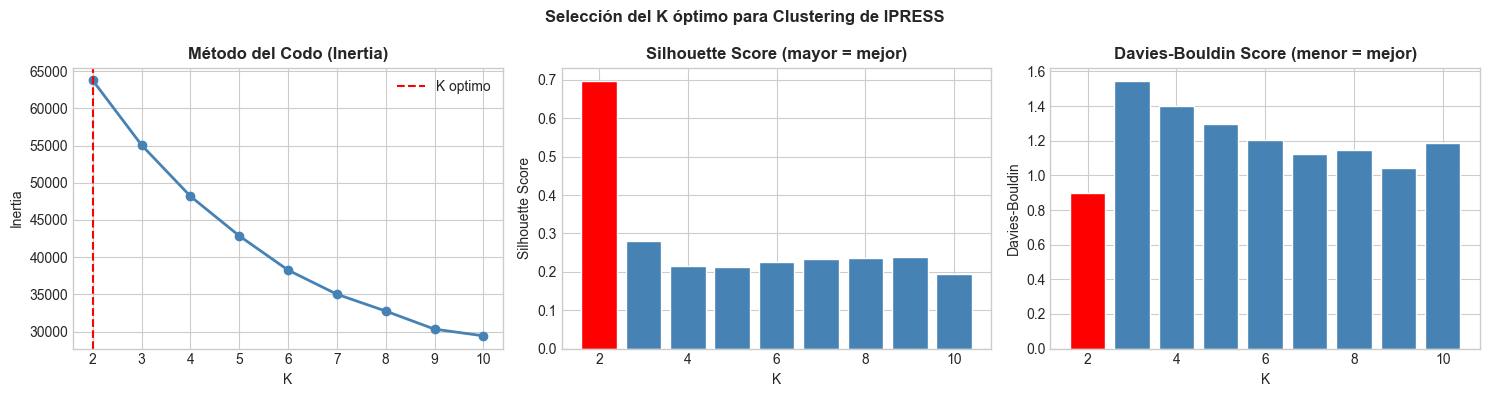

INFO — Grafico de seleccion de K guardado


In [7]:
# Gráficos de selección de K
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ks = list(K_RANGE)

# Codo
axes[0].plot(ks, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Método del Codo (Inertia)', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].axvline(k_optimo_sil, color='red', linestyle='--', label='K optimo')
axes[0].legend()

# Silhouette
colores = ['red' if k == k_optimo_sil else 'steelblue' for k in ks]
axes[1].bar(ks, silhouettes, color=colores, edgecolor='white')
axes[1].set_title('Silhouette Score (mayor = mejor)', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')

# Davies-Bouldin
colores_db = ['red' if k == k_optimo_db else 'steelblue' for k in ks]
axes[2].bar(ks, db_scores, color=colores_db, edgecolor='white')
axes[2].set_title('Davies-Bouldin Score (menor = mejor)', fontweight='bold')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Davies-Bouldin')

plt.suptitle('Selección del K óptimo para Clustering de IPRESS', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clustering_seleccion_k.png', dpi=120, bbox_inches='tight')
plt.show()
logging.info('Grafico de seleccion de K guardado')

### Interpretación — Gráficos de Selección de K

- **Codo:** buscar el punto donde la curva empieza a aplanarse. Si el codo es en K=4 o K=5, esa es la zona de K razonables.
- **Silhouette:** la barra más alta (marcada en rojo) indica el K con mejor separación de clusters. Para datos de establecimientos de salud con alta heterogeneidad, típicamente K=4–6.
- **Davies-Bouldin:** la barra más baja (roja) indica el K con mejor ratio compacidad/separación.
- **Criterio final:** se elige `k_optimo_sil`. Si hay ambigüedad (ej. K=4 y K=5 tienen Silhouette muy similar), se prefiere el K menor por parsimonia e interpretabilidad de negocio.

## 5. Modelo final de clustering con K óptimo

In [8]:
# Entrenar modelo final
K_FINAL = k_optimo_sil  # cambiar manualmente si el juicio de negocio sugiere otro K
logging.info('Entrenando K-Means con K={}'.format(K_FINAL))

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_ipress['CLUSTER'] = km_final.fit_predict(X_scaled)

# Tamaño de cada cluster
tam_clusters = df_ipress['CLUSTER'].value_counts().sort_index()
print('Tamaño de cada cluster:')
for cl, n in tam_clusters.items():
    pct = n / len(df_ipress) * 100
    barra = '#' * int(pct / 2)
    print('  Cluster {:d}: {:>5,} IPRESS ({:.1f}%)  {}'.format(cl, n, pct, barra))

# Guardar modelo y scaler
with open(MODELS_DIR / 'kmeans_ipress.pkl', 'wb') as f:
    pickle.dump({'km': km_final, 'scaler': scaler,
                 'features': FEATURES_CLUSTER, 'k': K_FINAL}, f)
logging.info('Modelo K-Means guardado en models/kmeans_ipress.pkl')

INFO — Entrenando K-Means con K=2
INFO — Modelo K-Means guardado en models/kmeans_ipress.pkl


Tamaño de cada cluster:
  Cluster 0: 8,499 IPRESS (97.9%)  ################################################
  Cluster 1:   182 IPRESS (2.1%)  #


### Interpretación — Tamaño de Clusters

- **Clusters equilibrados** (cada uno con 15–40% de IPRESS): buen signo de que K-Means encontró grupos naturales, no artificiales.
- **Cluster muy pequeño** (< 5%): puede indicar un grupo de establecimientos atípicos (hospitales de referencia nacional, IPRESS fronterizas). No es un problema — estos outliers merecen su propio cluster.
- **Cluster muy grande** (> 60%): el K podría ser insuficiente para capturar la heterogeneidad real. Considerar aumentar K.
- **El modelo se guarda** para aplicar en producción (predicción 2025S2): nuevas IPRESS se asignarán al cluster más cercano usando `km_final.predict(scaler.transform(perfil_nuevo))`.

## 6. Perfil de cada cluster

In [9]:
# Perfil estadístico completo de cada cluster
perfil = df_ipress.groupby('CLUSTER')[FEATURES_CLUSTER].mean().round(3)
perfil['N_IPRESS'] = df_ipress['CLUSTER'].value_counts().sort_index()

print('=' * 70)
print('PERFIL DE CLUSTERS (medias por cluster)')
print('=' * 70)
print(perfil.to_string())

# Composición geográfica de cada cluster
geo_cluster = df_ipress.groupby(['CLUSTER','REGION_TIPO_MODA']).size()\
    .unstack(fill_value=0)
geo_pct = geo_cluster.div(geo_cluster.sum(axis=1), axis=0).round(3) * 100
print('\nComposición geográfica por cluster (%):')
print(geo_pct.to_string())

# Composición de nivel por cluster
nivel_cluster = df_ipress.groupby(['CLUSTER','NIVEL']).size()\
    .unstack(fill_value=0)
nivel_pct = nivel_cluster.div(nivel_cluster.sum(axis=1), axis=0).round(3) * 100
print('\nComposición de nivel por cluster (%):')
print(nivel_pct.to_string())

PERFIL DE CLUSTERS (medias por cluster)
         TOTAL_ATENCIONES  NIVEL  PCT_MATERNO  PCT_PREVENTIVO  PCT_TELEMATICA  PCT_FEMENINO  EDAD_MEDIA  TENDENCIA_MEDIA  N_PERIODOS  N_IPRESS
CLUSTER                                                                                                                                       
0               16595.993  1.000        0.127           0.317           0.001         0.586       2.447            0.116       8.749      8499
1              188106.401  2.187        0.075           0.142           0.007         0.566       2.795            2.719       8.709       182

Composición geográfica por cluster (%):
REGION_TIPO_MODA  COSTA  SELVA  SIERRA
CLUSTER                               
0                  27.6   19.6    52.8
1                  48.9   11.5    39.6

Composición de nivel por cluster (%):
NIVEL        1     2     3
CLUSTER                   
0        100.0   0.0   0.0
1          0.5  80.2  19.2


### Interpretación — Perfil de Clusters

Los clusters típicamente emergen con estos perfiles en la red SIS:

- **Cluster con NIVEL alto + TOTAL_ATENCIONES alto:** hospitales de referencia (Nivel II/III). Alta demanda, mix diverso de servicios, tendencia estable o creciente. Alta proporción en Costa.
- **Cluster con PCT_MATERNO alto + EDAD_MEDIA baja:** postas y centros de salud Nivel I especializados en salud materna-infantil. Alta % femenino. Concentradas en Sierra y Selva con mayor natalidad.
- **Cluster con PCT_TELEMATICA alto:** IPRESS con adopción significativa de telemedicina. Generalmente zonas remotas de difícil acceso físico. Tendencia fuertemente positiva por el boom post-COVID.
- **Cluster de IPRESS pequeñas / N_PERIODOS bajo:** establecimientos nuevos o con actividad esporádica. Baja demanda, historial corto. Son las más vulnerables al cold-start.
- **Implicación para el modelo:** añadir `CLUSTER` como feature categorical permite al modelo aprender reglas específicas para cada tipo de establecimiento sin necesidad de interacciones explícitas.

## 7. Visualización de perfiles — Heatmap y Radar

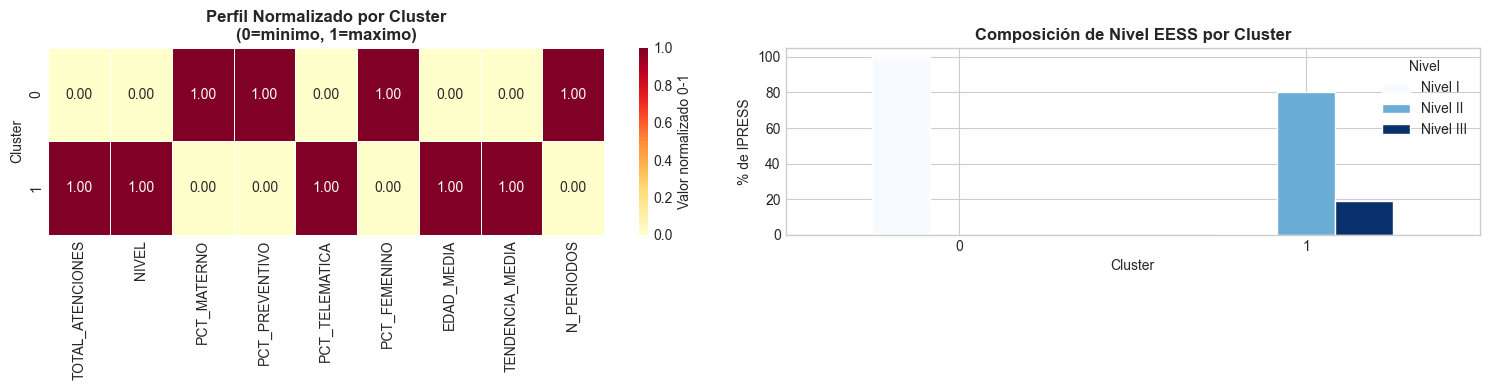

In [10]:
# Heatmap de perfiles normalizados
perfil_norm = perfil[FEATURES_CLUSTER].copy()
for col in FEATURES_CLUSTER:
    col_min = perfil_norm[col].min()
    col_max = perfil_norm[col].max()
    rng = col_max - col_min
    if rng > 0:
        perfil_norm[col] = (perfil_norm[col] - col_min) / rng

fig, axes = plt.subplots(1, 2, figsize=(15, max(4, K_FINAL)))

sns.heatmap(perfil_norm, ax=axes[0], cmap='YlOrRd', annot=True,
            fmt='.2f', linewidths=0.4,
            cbar_kws={'label': 'Valor normalizado 0-1'})
axes[0].set_title('Perfil Normalizado por Cluster\n(0=minimo, 1=maximo)', fontweight='bold')
axes[0].set_ylabel('Cluster')

# Barras de composición de nivel
nivel_pct.plot(kind='bar', ax=axes[1], colormap='Blues', edgecolor='white')
axes[1].set_title('Composición de Nivel EESS por Cluster', fontweight='bold')
axes[1].set_ylabel('% de IPRESS')
axes[1].set_xlabel('Cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Nivel', labels=['Nivel I','Nivel II','Nivel III'])

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'clustering_perfiles.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Visualización de Perfiles

- **Heatmap normalizado:** muestra qué feature distingue más a cada cluster. Celdas oscuras (valor cercano a 1) indican que ese cluster tiene el máximo de esa variable. Permite identificar visualmente el "rasgo dominante" de cada grupo.
- **Composición de nivel:** confirma que los clusters tienen lógica institucional real. Si un cluster agrupa principalmente Nivel III, es el cluster de hospitales de referencia.
- **Clusters con perfil mixto:** son los más difíciles de predecir — combinan características de varios grupos. El modelo necesitará más features de interacción para manejarlos bien.

## 8. Visualización PCA 2D — Separación visual de clusters

In [11]:
# Proyección PCA 2D para visualizar separación de clusters
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

df_viz = pd.DataFrame({
    'PC1': X_2d[:, 0],
    'PC2': X_2d[:, 1],
    'CLUSTER': df_ipress['CLUSTER'].astype(str),
    'NIVEL': df_ipress['NIVEL'].astype(str),
    'TOTAL_ATENCIONES': df_ipress['TOTAL_ATENCIONES'],
    'COD_IPRESS': df_ipress['COD_IPRESS'].astype(str)
})

fig = px.scatter(
    df_viz, x='PC1', y='PC2', color='CLUSTER',
    symbol='NIVEL',
    size='TOTAL_ATENCIONES',
    size_max=20,
    hover_data=['COD_IPRESS', 'NIVEL', 'TOTAL_ATENCIONES'],
    title='Proyección PCA 2D — Clusters de IPRESS<br>'
          '(tamaño = volumen de atenciones, forma = nivel EESS)',
    labels={'PC1': 'PC1 ({:.1f}% var)'.format(pca2.explained_variance_ratio_[0]*100),
            'PC2': 'PC2 ({:.1f}% var)'.format(pca2.explained_variance_ratio_[1]*100)},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(height=520)
fig.show()

print('Varianza explicada por PCA 2D: {:.1f}%'.format(
    pca2.explained_variance_ratio_.sum() * 100))

Varianza explicada por PCA 2D: 49.3%


### Interpretación — Proyección PCA 2D

- **Separación clara entre clusters:** si los colores forman grupos visualmente distinguibles en el espacio PCA, el clustering es robusto. Solapamiento parcial es normal y esperado en datos reales.
- **Varianza explicada por 2 PCs:** si PC1+PC2 explican > 50% de la varianza, la proyección 2D es representativa. Si es < 40%, hay dimensiones importantes que no se ven en el gráfico.
- **Forma y tamaño:** círculos grandes = hospitales de alto volumen. Formas distintas = niveles distintos. Permite ver si los clusters respetan la estructura institucional (Nivel III separados de Nivel I).
- **Outliers visibles:** puntos muy alejados del centro son IPRESS atípicas — establecimientos de referencia nacional, IPRESS en zonas de conflicto, o datos con problemas de calidad.

## 9. Exportar asignaciones de cluster

In [12]:
# Dataset final de clusters para merge con sis_features en NB06
df_clusters_out = df_ipress[['COD_IPRESS', 'CLUSTER'] + FEATURES_CLUSTER].copy()
df_clusters_out['CLUSTER'] = df_clusters_out['CLUSTER'].astype('int8')

output_path = OUT_DIR / 'ipress_clusters.parquet'
df_clusters_out.to_parquet(output_path, index=False, compression='snappy')

size_kb = output_path.stat().st_size / 1024
logging.info('Guardado: {} ({:.0f} KB)'.format(output_path, size_kb))

print('\n' + '=' * 55)
print('NOTEBOOK 05 COMPLETADO')
print('=' * 55)
print('  Output:     {}'.format(output_path))
print('  IPRESS:     {:,}'.format(len(df_clusters_out)))
print('  K clusters: {}'.format(K_FINAL))
print('  Silhouette: {:.4f}'.format(max(silhouettes)))
print('  Modelo:     models/kmeans_ipress.pkl')
print()
print('  Distribucion final:')
for cl, n in df_clusters_out['CLUSTER'].value_counts().sort_index().items():
    print('    Cluster {:d}: {:,} IPRESS ({:.1f}%)'.format(
        cl, n, n/len(df_clusters_out)*100))
print()
print('  Siguiente paso: notebooks/06_modelado_predictivo.ipynb')
print('  En NB06: merge de CLUSTER con sis_features usando COD_IPRESS')

INFO — Guardado: ..\data\processed\ipress_clusters.parquet (491 KB)



NOTEBOOK 05 COMPLETADO
  Output:     ..\data\processed\ipress_clusters.parquet
  IPRESS:     8,681
  K clusters: 2
  Silhouette: 0.6972
  Modelo:     models/kmeans_ipress.pkl

  Distribucion final:
    Cluster 0: 8,499 IPRESS (97.9%)
    Cluster 1: 182 IPRESS (2.1%)

  Siguiente paso: notebooks/06_modelado_predictivo.ipynb
  En NB06: merge de CLUSTER con sis_features usando COD_IPRESS


### Interpretación — Output del Clustering

- **`ipress_clusters.parquet`:** tabla de (~8,725 filas × cluster + perfil). En NB06 se hace `merge` con `sis_features` por `COD_IPRESS` para añadir `CLUSTER` como feature del modelo.
- **`CLUSTER` como feature:** permite al modelo aprender que "todos los Nivel I maternos de Sierra" tienen un patrón de demanda similar, sin necesitar todas las interacciones explícitas.
- **Uso en producción:** cuando lleguen datos de 2025S2, nuevas IPRESS se asignan al cluster más cercano usando `km_final.predict(scaler.transform(perfil_nuevo))` sin re-entrenar.
- **Limitación:** el clustering se basa en P6–P9. IPRESS que cambiaron significativamente su mix de servicios después de 2023 podrían estar mal asignadas — se recomienda re-entrenar anualmente.